In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import pandas as pd
import os
import pingouin as pg
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose
from sqlalchemy import create_engine
from dotenv import load_dotenv

In [2]:
# Global style settings
plt.rcParams.update({
    'figure.figsize': (10, 7),   # Size of all plots
    'axes.grid': True,           # Enable grid
    'grid.alpha': 0.3,           # Grid transparency
    'grid.linestyle': '--',      # Grid style
    'font.size': 12,             # Base font size
    'axes.titlesize': 16,        # Title size
    'axes.labelsize': 14,        # Axis labels
})
plt.style.use('dark_background')

In [3]:
# Load credentials from .env
load_dotenv()
PG_URI = os.getenv("DATABASE_URL")

if not PG_URI:
    raise ValueError("DATABASE_URL not found. Check your .env file.")

# Initialize engine
engine = create_engine(PG_URI)

def get_donations():
    query = """
    SELECT
        d.id, d.date, d.foundation_name, d.category,
        ROUND((d.amount / NULLIF(er.rate_uah, 0))::numeric, 2) AS amount_eur,
        er.rate_uah AS eur_exchange_rate,
        d.currency AS original_currency,
        d.comment, d.source AS donation_source
    FROM donations d    
    LEFT JOIN exchange_rates er ON d.date = er.date AND er.currency = 'EUR'
    WHERE d.date >= '2025-01-01'
    ORDER BY d.date DESC;
    """
    return pd.read_sql(query, engine, parse_dates=['date'])

def get_news():
    query = """
    SELECT
        date,
        STRING_AGG(source, ' | ') AS daily_sources,
        STRING_AGG(headers, ' | ') AS daily_headers
    FROM news
    GROUP BY date
    ORDER BY date DESC;
    """
    return pd.read_sql(query, engine, parse_dates=['date'])

# Execution
df_donations = get_donations()
df_news = get_news()

# Global formatting settings
pd.options.display.float_format = '{:,.2f}'.format
pd.options.display.max_colwidth = 80

print(f"Extraction successful. Donations: {len(df_donations)} | News: {len(df_news)}")

Extraction successful. Donations: 2066994 | News: 444


In [4]:
df = df_donations.copy()
df.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source
0,9685870,2026-04-10,come_back_alive,general,1.48,50.80,UAH,UKR ***6661 (75 UAH),Card payment
1,9685869,2026-04-10,come_back_alive,general,0.98,50.80,UAH,UKR ***3590 (50 UAH),Card payment
2,9685868,2026-04-10,come_back_alive,general,14.76,50.80,UAH,UKR ***6126 (750 UAH),Card payment
3,9685867,2026-04-10,come_back_alive,general,4.92,50.80,UAH,UKR ***8663 (250 UAH),Card payment
4,9685866,2026-04-10,come_back_alive,general,49.92,50.80,EUR,IRL ***6176 (50 EUR),Card payment


In [5]:
news = df_news.copy()
news.head()

,date,daily_sources,daily_headers
0,2026-04-10,theguardian.com,"[""Ukraine war briefing: First official ceasefire agreed after Zelenskyy push..."
1,2026-04-09,theguardian.com,"[""\u2018I had poked the bear right in the eye\u2019: my fight to renounce my..."
2,2026-04-08,theguardian.com,"[""Ukraine war briefing: Kyiv lays out how \u2018Russian satellites help Iran..."
3,2026-04-07,theguardian.com,"[""Ukraine war briefing: Zelenskyy reiterates truce offer ahead of Orthodox E..."
4,2026-04-06,theguardian.com,['Ukraine war briefing: Russian oil facilities burn as Zelenskyy tours Middl...


Here I’ll again work only with CBA Foundation data, because United24 gives only aggregated daily numbers and we can’t split them into proper segments.This time I’m going to look at business donations. I’m assuming that grassroots donors rarely send 10k euros or more, so I’m filtering the table to only CBA and donations from €10,000 upwards.

In [6]:
df = df.query('foundation_name == "come_back_alive" & amount_eur > 10000').copy()

Let's check weekly dynamics

In [7]:
df['week_start']  = df['date'].dt.to_period('W').dt.start_time

In [8]:
whales = df.groupby(['week_start', 'original_currency'], as_index = False)\
            .agg(amount = ('amount_eur', 'sum'))\
            .sort_values('week_start')\
            
whales.head()

,week_start,original_currency,amount
0,2024-12-30,UAH,"423,222.31"
1,2024-12-30,USD,"19,383.61"
2,2025-01-06,UAH,"1,015,911.53"
3,2025-01-13,UAH,"141,767.25"
4,2025-01-13,USD,"135,935.37"


Perfect, now we have a nice clean dataframe segmented by currency to work with

<Axes: xlabel='week_start', ylabel='amount'>

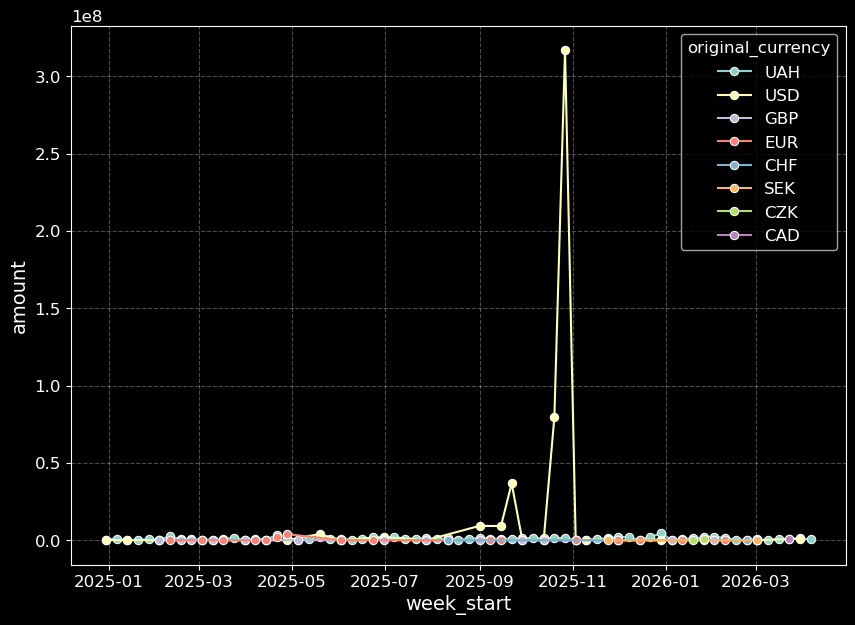

In [9]:
sns.lineplot(whales, x = 'week_start', y = 'amount', hue = 'original_currency', marker='o' )
#plt.legend()


Wow, that November–December peak is enormous! It completely dwarfs everything else and turns the rest of the donations into background noise.  Time to dig deeper into this period.

In [10]:
peak = whales[(whales.week_start > '2025-09-20') & (whales.week_start < '2025-11-10')].reset_index(drop = True)

<Axes: xlabel='week_start', ylabel='amount'>

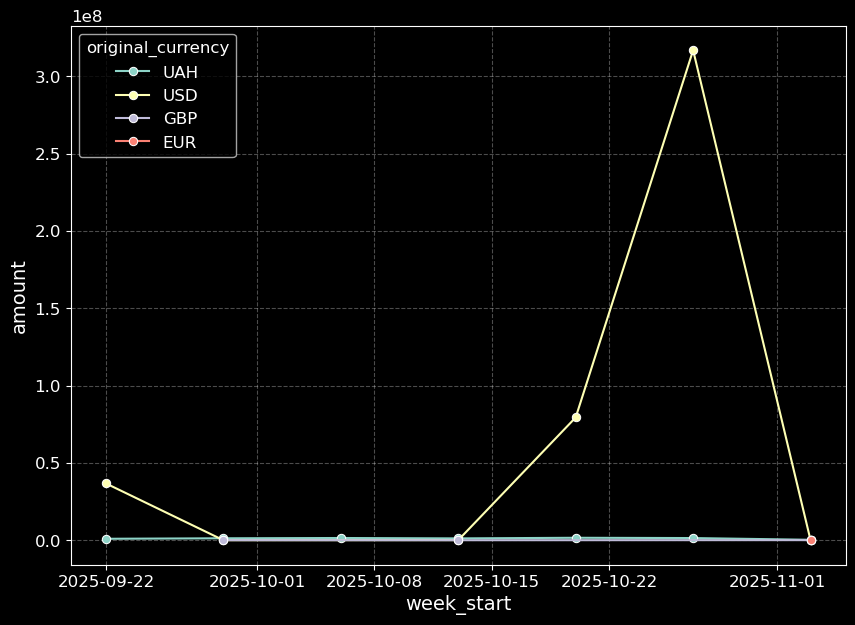

In [11]:
sns.lineplot(peak, x = 'week_start', y = 'amount', hue = 'original_currency', marker='o')

Let's look even closer

In [12]:
peak = whales[(whales.week_start > '2025-10-08') & (whales.week_start < '2025-11-15')].reset_index(drop = True)

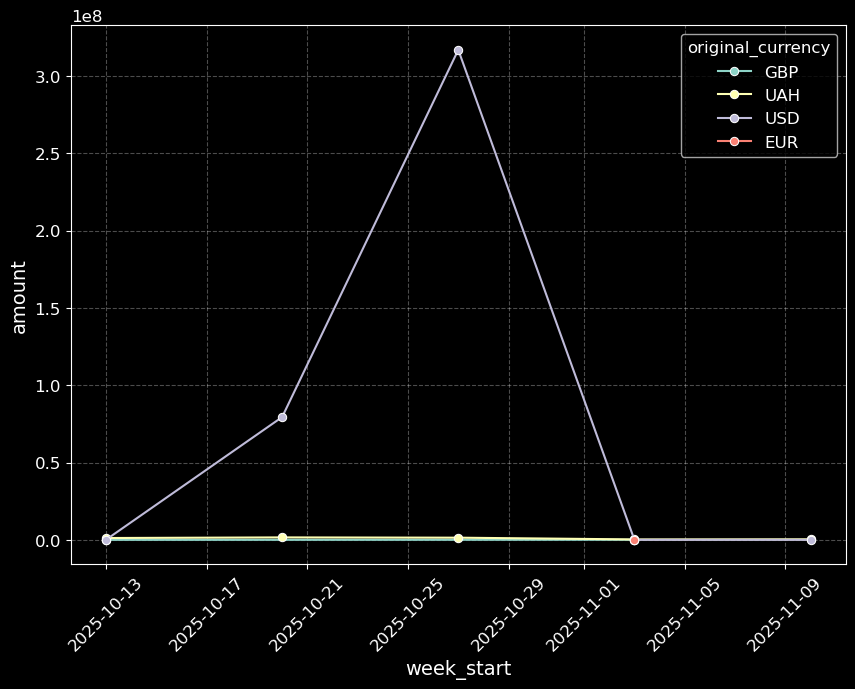

In [13]:
sns.lineplot(peak, x = 'week_start', y = 'amount' , hue = 'original_currency', marker='o')
plt.xticks(rotation = 45)
plt.show()

In [14]:
start, end = '2025-10-13', '2025-10-29'

In [15]:
peak_news = news[news.date.between(start, end)].reset_index()
print(f'Found {len(peak_news)}')
b

Found 17


,index,date,daily_sources,daily_headers
0,161,2025-10-29,kyivindependent.com | theguardian.com,"[""Gripen jets are coming to Ukraine — here's how they can be used against Ru..."
1,162,2025-10-28,kyivindependent.com | theguardian.com,"['Russian troops outnumber Ukraine 8-1 in Pokrovsk sector, Zelensky says', '..."
2,163,2025-10-27,kyivindependent.com | theguardian.com,"[""Ukraine war latest updates: HUR 'liquidates' son of Russian general, relea..."
3,164,2025-10-26,theguardian.com,['Trump sanctions have swift impact but will world stop buying Russian oil a...
4,165,2025-10-25,kyivindependent.com | theguardian.com,"[""Ukrainian drones strike electrical substation in Russia's Volgograd Oblast..."


In [20]:
peak_news.shape

(17, 4)

In [19]:
for i in peak_news.daily_headers:
    print(i)

["Gripen jets are coming to Ukraine — here's how they can be used against Russia", 'Ukraine closes embassy in Cuba over Russian military recruitment'] | ['Ukraine war briefing: Moscow under drone siege for third night running', 'Putin under pressure? Inside the 31 October Guardian Weekly']
['Russian troops outnumber Ukraine 8-1 in Pokrovsk sector, Zelensky says', 'Russian drone strikes German newspaper Die Welt team in eastern Ukraine, 3 wounded', "Ukraine's ex-grid operator chief detained a week after raid on home he called politically motivated"] | ['Teenager from Gaza ‘stuck in hell’ after being prevented from joining mother in UK', '‘It’s more about life than death’: the growing popularity of Berlin’s cemetery cafes', 'Ukraine war briefing: Russian drones hunt civilians in crime against humanity, UN inquiry finds', 'Russian drone attacks on civilians in Ukraine are war crimes, UN report concludes']
["Ukraine war latest updates: HUR 'liquidates' son of Russian general, releases foot

The same old story: Trump refuses to help Ukraine, Trump listens to Putin, and so on. I doubt that this is what caused such a spike (since this has been ongoing throughout Trump’s term). Let’s take a closer look at where exactly all this money came from.

In [21]:
dates = peak_news.date

In [22]:
# cutting df to explore closer rush dates
peak_df = df[df.date.isin(dates)].reset_index()
peak_df.head()

,index,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
0,591916,7808555,2025-10-29,come_back_alive,general,"79,048,013.00",48.98,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
1,593017,7807514,2025-10-29,come_back_alive,general,"20,417.16",48.98,UAH,"ТОВ ""МІТ УКРАЇНА"" -- Благодійна допомога військовослужбовцям",Privat,2025-10-27
2,593018,7807515,2025-10-29,come_back_alive,general,"17,251.24",48.98,UAH,"ТОВ ""АСФ ТРЕЙД"" -- Благодійна допомога військовослужбовцям",Privat,2025-10-27
3,593020,7807517,2025-10-29,come_back_alive,general,"22,560.97",48.98,UAH,"ТОВ ""РУХ ФІНАНС"" -- Благодійна допомога військовослужбовцям",Privat,2025-10-27
4,593021,7807518,2025-10-29,come_back_alive,general,"30,625.75",48.98,UAH,"ТОВ ""МАКРО ГРОССЕРІ"" -- Благодійна допомога військовослужбовцям",Privat,2025-10-27


In [23]:
# Top 6 donations in this period
top6 = peak_df.sort_values('amount_eur', ascending = False).reset_index().head(6)
top6

,level_0,index,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
0,40,615047,7785246,2025-10-23,come_back_alive,general,"79,419,876.37",48.37,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-20
1,25,598208,7802323,2025-10-27,come_back_alive,general,"79,228,384.88",48.77,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
2,0,591916,7808555,2025-10-29,come_back_alive,general,"79,048,013.00",48.98,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
3,13,595304,7805220,2025-10-28,come_back_alive,general,"79,030,934.66",48.97,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
4,27,599638,7800819,2025-10-27,come_back_alive,general,"410,115.08",48.77,UAH,"АТ ""КОНЦЕРН ГАЛНАФТОГАЗ"" -- Благодійна пожертва",Oschad,2025-10-27
5,49,615106,7785037,2025-10-23,come_back_alive,general,"243,594.02",48.37,UAH,"Акціонерне товариство ""Укрнафта -- Безповоротна фінансова благодійна допомога",Oschad,2025-10-20


Yes, we identified the source of the “mysterious” spike — transfers labeled “To support Ukrainian Defence according to the Grant Agreement” from the USA. Most likely, this reflects one of the final funding tranches from the Biden administration. Let's see how many they transfered during the whole period from 2025-01-01

In [24]:
# Finding thw US help
usa = df[df.comment == 'To support Ukrainian Defence according to the Grant Agreement']
usa

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
584519,7821966,2025-10-31,come_back_alive,general,"79,591,723.49",48.51,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
591916,7808555,2025-10-29,come_back_alive,general,"79,048,013.00",48.98,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
595304,7805220,2025-10-28,come_back_alive,general,"79,030,934.66",48.97,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
598208,7802323,2025-10-27,come_back_alive,general,"79,228,384.88",48.77,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-27
615047,7785246,2025-10-23,come_back_alive,general,"79,419,876.37",48.37,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-10-20
834390,6171111,2025-09-05,come_back_alive,general,"9,277,560.52",48.13,USD,To support Ukrainian Defence according to the Grant Agreement,Universal,2025-09-01


In [25]:
# Total USA help to Come Back Alive
usa.amount_eur.sum()

405596492.91999996

400+ million is impressive. Let’s exclude that from our analysis and focus on business support rather than the USA.

In [26]:
# Deleting USA huge donations
df_clean = df.drop(usa.index)
df_clean_week = df_clean.groupby('week_start', as_index = False).agg({'amount_eur':'sum'})

<Axes: xlabel='week_start', ylabel='amount_eur'>

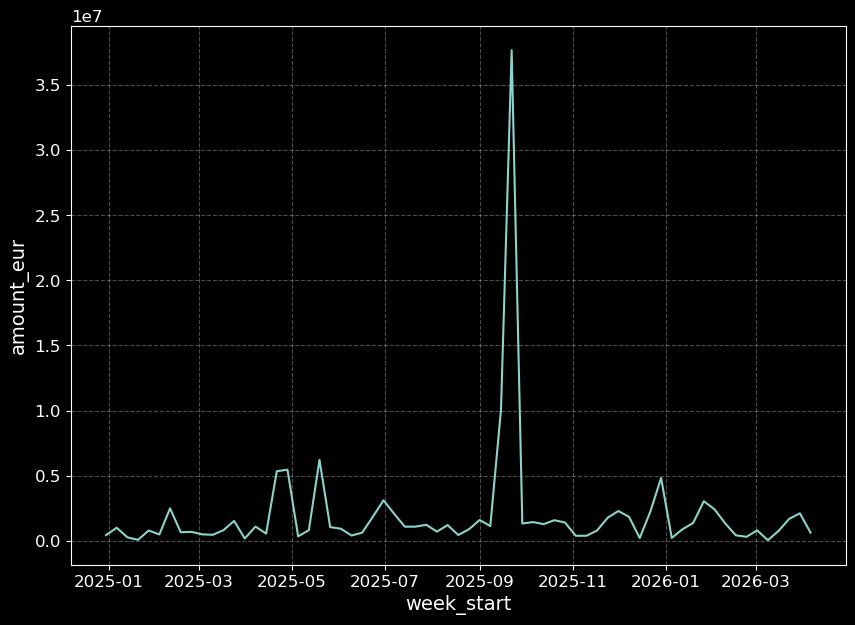

In [27]:
sns.lineplot(df_clean_week, x = 'week_start', y = 'amount_eur')

Another huge peak almost the same period!

In [28]:
peak_df = df_clean[df_clean['date'].between('2025-09-10', '2025-10-10')]

In [29]:
peak_df.sort_values('amount_eur', ascending = False).head(7)

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
777413,6701450,2025-09-22,come_back_alive,general,"9,200,503.08",48.42,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
774230,6705040,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
774493,6705039,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
774231,6705041,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
786077,6540409,2025-09-19,come_back_alive,general,"9,131,639.64",48.78,USD,For the needs of Ukrainian Defence,Universal,2025-09-15
749250,6781147,2025-10-01,come_back_alive,general,"517,568.34",48.30,UAH,"ТОВ ""ОККО-ДРАЙВ"" -- Благодійна пожертва",Oschad,2025-09-29
819173,6180446,2025-09-10,come_back_alive,general,"268,632.64",48.29,UAH,Акцiонерне товариство 'Укрнафта' -- Безповоротна фiнансова благодiйна допомога,Oschad,2025-09-08


Yep, we found more USA transhes "For the needs of Ukrainian Defence", let's see are there more of them

In [30]:
df_clean[df_clean.comment  == 'For the needs of Ukrainian Defence']

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
332767,9320695,2025-12-29,come_back_alive,general,"372,192.81",49.56,USD,For the needs of Ukrainian Defence,Tascombank,2025-12-29
774230,6705040,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
774231,6705041,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
774493,6705039,2025-09-23,come_back_alive,general,"9,171,192.52",48.73,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
777413,6701450,2025-09-22,come_back_alive,general,"9,200,503.08",48.42,USD,For the needs of Ukrainian Defence,Universal,2025-09-22
786077,6540409,2025-09-19,come_back_alive,general,"9,131,639.64",48.78,USD,For the needs of Ukrainian Defence,Universal,2025-09-15


No, there aren’t. Let’s exclude them as well, but keep the one that clearly stands out.

In [31]:
usa_aid = df_clean[df_clean.comment  == 'For the needs of Ukrainian Defence'][1:]

In [32]:
df_clean = df_clean.drop(usa_aid.index)

<Axes: xlabel='week_start', ylabel='amount_eur'>

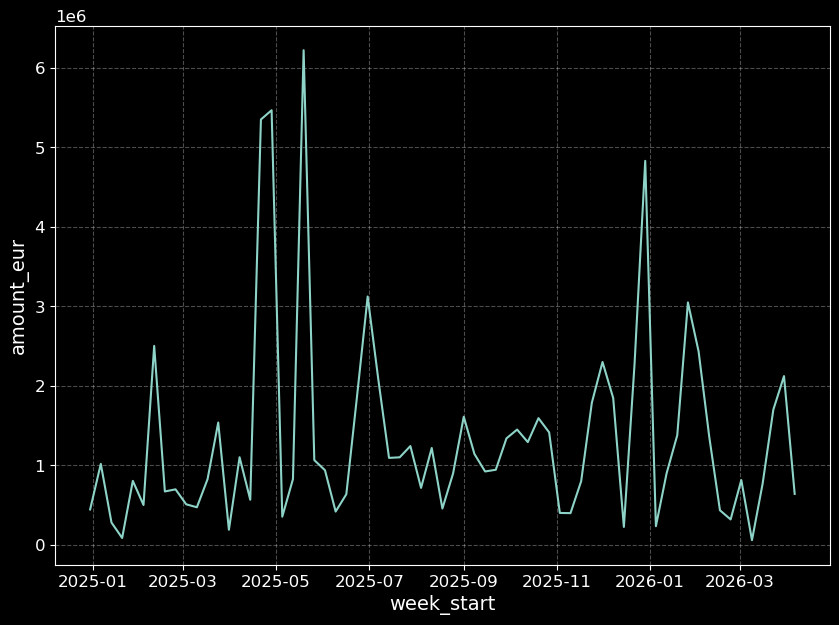

In [33]:
df_clean_week = df_clean.groupby('week_start', as_index = False).agg({'amount_eur':'sum'})
sns.lineplot(df_clean_week, x = 'week_start', y = 'amount_eur')

Well, only 3 peaks left, let's repeat that same routine

In [34]:
new_peaks = df[df.date.between('2025-04-01', '2025-06-01')]

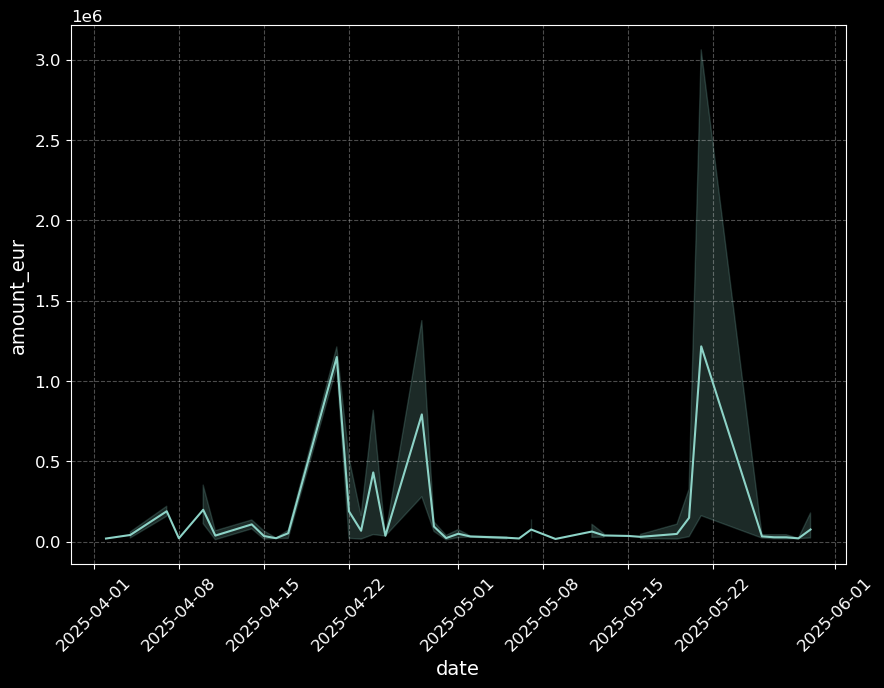

In [35]:
sns.lineplot(new_peaks, x = 'date', y = 'amount_eur')
plt.xticks(rotation = 45)
plt.show()

In [36]:
new_peaks = df[df.date.between('2025-04-15', '2025-04-22') | df.date.between ('2025-04-25', '2025-05-01') ]

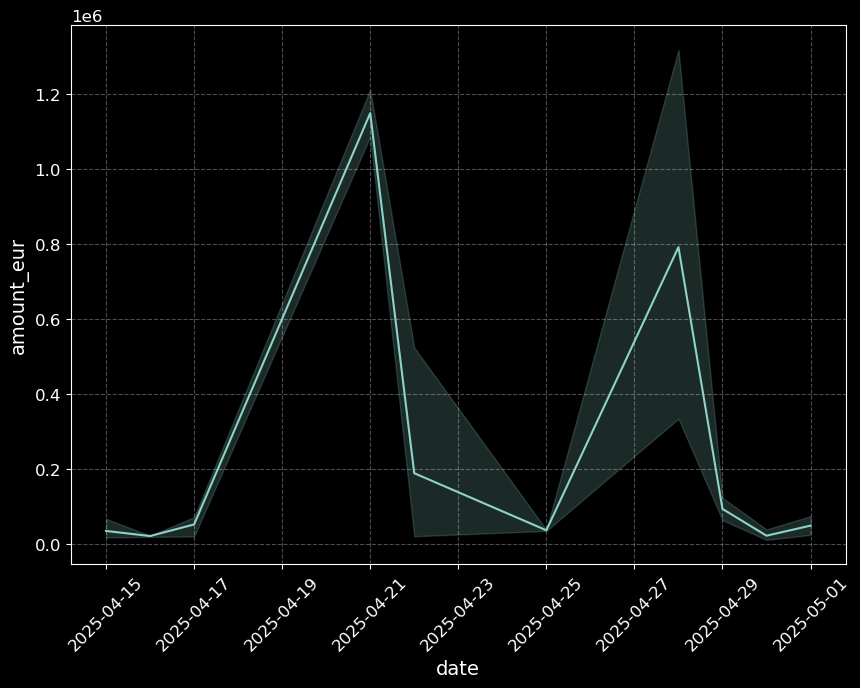

In [37]:
sns.lineplot(new_peaks, x = 'date', y = 'amount_eur')
plt.xticks(rotation = 45)
plt.show()

In [38]:
new_peaks.shape

(37, 10)

In [39]:
new_peaks.sort_values('amount_eur', ascending = False).reset_index().head(10)

,index,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
0,1461712,7623153,2025-04-28,come_back_alive,general,"1,722,495.16",47.39,EUR,DONATION: COME BACK ALIVE ORG. DONATION: COME BACK ALIVE ORG.,Universal,2025-04-28
1,1461934,5336955,2025-04-28,come_back_alive,general,"1,600,219.48",47.39,EUR,Fritt Ukraina -- CHARITABLE WORK (1 600 000.00 EUR),Privat,2025-04-28
2,1484038,5312706,2025-04-21,come_back_alive,general,"1,211,243.73",47.03,UAH,"ППО ДП НЕК ""Укренерго"" -- Благодійна допомога (пожертва) згідно додаткової у...",Oschad,2025-04-21
3,1484039,5312707,2025-04-21,come_back_alive,general,"1,085,585.84",47.03,UAH,"ППО ДП НЕК ""Укренерго"" -- Благодійна допомога (пожертва) згідно додаткової у...",Oschad,2025-04-21
4,1463373,5333497,2025-04-28,come_back_alive,general,"633,103.73",47.39,UAH,"БО ""БФ ""ХАРТІЯ"" -- Благодійна допомога",Oschad,2025-04-28
5,1461933,5336954,2025-04-28,come_back_alive,general,"625,085.73",47.39,EUR,Fritt Ukraina -- CHARITABLE WORK (625 000.00 EUR),Privat,2025-04-28
6,1480508,5316196,2025-04-22,come_back_alive,general,"523,392.50",47.77,UAH,"ТОВ ""ОККО-ДРАЙВ"" -- Благодійна пожертва",Oschad,2025-04-21
7,1461926,5335258,2025-04-28,come_back_alive,general,"126,620.75",47.39,UAH,"АТ ""СЕНС БАНК"" Благодійна пожертва на проєкт ""Навчати перемагати""",Sense Bank,2025-04-28
8,1460465,5336310,2025-04-29,come_back_alive,general,"122,774.47",47.39,UAH,"ТОВ""АДД-ГРУПП"" -- Благодійна допомога військовослужбовцям",Privat,2025-04-28
9,1453339,5350857,2025-05-01,come_back_alive,general,"116,602.75",47.17,UAH,"ТОВ ""МОНСАРЗ"" -- Благодійна допомога військовослужбовцям",Privat,2025-04-28



I suspect these are actually donations from businesses — the so-called 'whales'. So I'll keep them for studying business behavior. Let's explore that final peak

In [40]:
final_peak = df[df.date.between('2025-05-20', '2025-05-26')] 

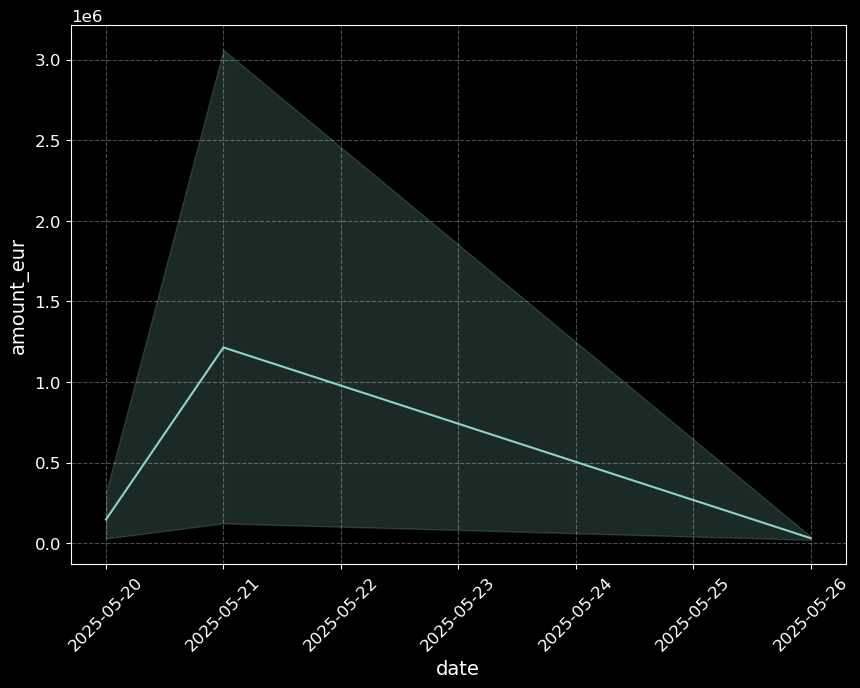

In [41]:
sns.lineplot(final_peak, x = 'date', y = 'amount_eur')
plt.xticks(rotation = 45)
plt.show()

In [42]:
final_peak.sort_values('amount_eur', ascending = False).reset_index().head(5)

,index,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
0,1365594,5443310,2025-05-21,come_back_alive,general,"4,001,598.00",46.65,USD,Donation Grant Agreement,Universal,2025-05-19
1,1371302,5434017,2025-05-20,come_back_alive,general,"642,497.68",46.86,UAH,"ПРАТ ""УКРГІДРОЕНЕРГО"" -- Пожертва згідно з",Oschad,2025-05-19
2,1367130,5438369,2025-05-21,come_back_alive,general,"535,881.56",46.65,UAH,"АТ ""КОНЦЕРН ГАЛНАФТОГАЗ"" -- Благодійна пожертва",Oschad,2025-05-19
3,1367109,5438348,2025-05-21,come_back_alive,general,"235,607.57",46.65,UAH,Публiчне акцiонерне товариство 'Укрнафта' -- Безповоротна фiнансова благодiй...,Oschad,2025-05-19
4,1371301,5434016,2025-05-20,come_back_alive,general,"211,172.54",46.86,UAH,"ПРАТ ""УКРГІДРОЕНЕРГО"" -- Пожертва згідно з",Oschad,2025-05-19


Bingo! We found that huge donation from the USA! 4,001,598.00 'Donation Grant Agreement'. Let's remove it from our cleaned dataframe

In [43]:
df_clean = df_clean.drop(1365594)
df_clean_weeks = df_clean.groupby('week_start', as_index = False)\
                    .agg(weekly_donations = ('amount_eur', 'sum'))\
                    .reset_index(drop = True)

Finally we have a dataframe to work with!

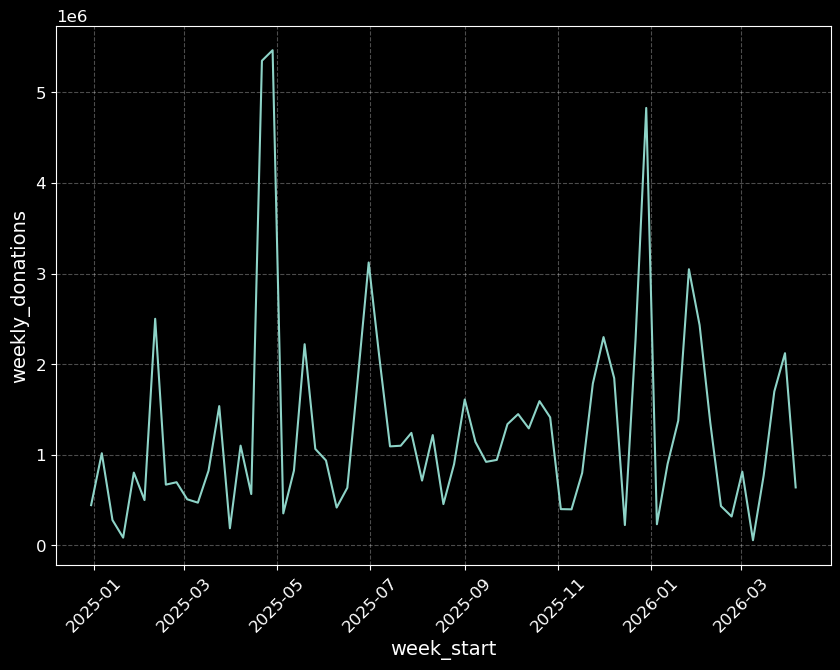

In [44]:
sns.lineplot(df_clean_weeks, x = 'week_start', y = 'weekly_donations')
plt.xticks(rotation = 45)
plt.show()

In [48]:
# Key metrics
df_clean.amount_eur.describe()

count       1,472.00
mean       58,369.19
std       140,733.14
min        10,041.24
25%        17,996.25
50%        21,214.92
75%        42,217.17
max     2,127,479.00
Name: amount_eur, dtype: float64

In [50]:
# Median business donations
df_clean.amount_eur.median()

21214.92

In [52]:
# Let's explore average and median donations from business in dynamics 
daily_stats = df_clean.groupby('date')['amount_eur'].sum().reset_index()
daily_stats = daily_stats.sort_values('date')

daily_stats['rolling_mean']   = daily_stats.amount_eur.rolling(window=7).mean()
daily_stats['rolling_median'] = daily_stats.amount_eur.rolling(window=7).median()

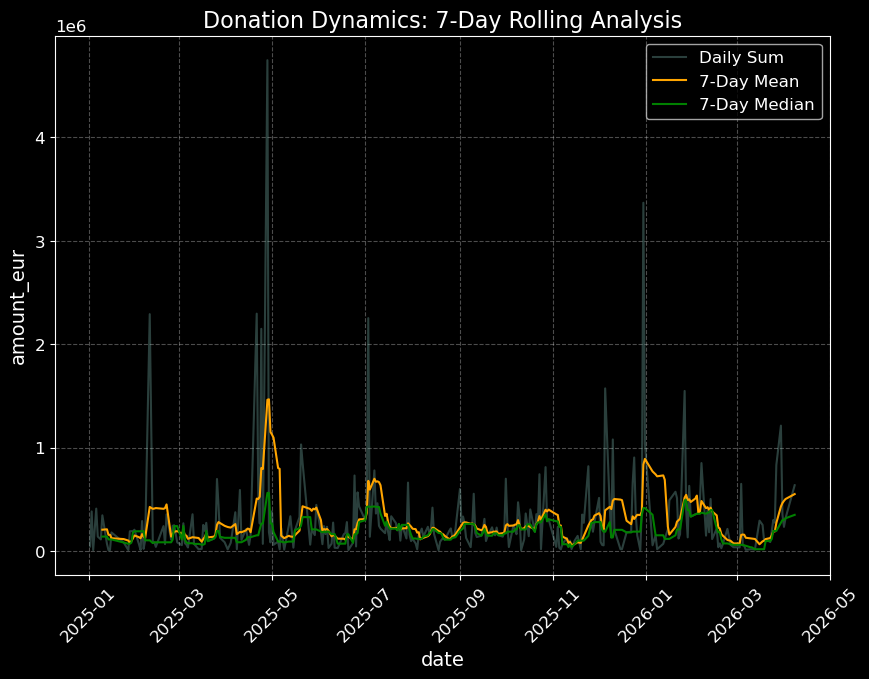

In [53]:
sns.lineplot(data=daily_stats, x='date', y='amount_eur', alpha=0.3, label='Daily Sum')
sns.lineplot(data=daily_stats, x='date', y='rolling_mean', color='orange', label='7-Day Mean')
sns.lineplot(data=daily_stats, x='date', y='rolling_median', color='green', label='7-Day Median')
plt.title('Donation Dynamics: 7-Day Rolling Analysis')
plt.xticks(rotation=45)
plt.show()

As we can observe, both the mean and the median remained relatively close to each other over the entire period. However, there were several significant spikes. Let’s now look at what caused these sharp increases.


In [59]:
spike1 = daily_stats[daily_stats.date.between('2025-02-05', '2025-02-13')]

In [60]:
spike1.head()

,date,amount_eur,rolling_mean,rolling_median
19,2025-02-05,"292,136.42","165,638.05","194,377.29"
20,2025-02-06,"23,037.18","141,364.57","194,377.29"
21,2025-02-07,"105,769.85","128,682.34","105,769.85"
22,2025-02-10,"2,292,012.78","428,344.56","105,769.85"
23,2025-02-12,"79,492.97","409,986.67","79,492.97"


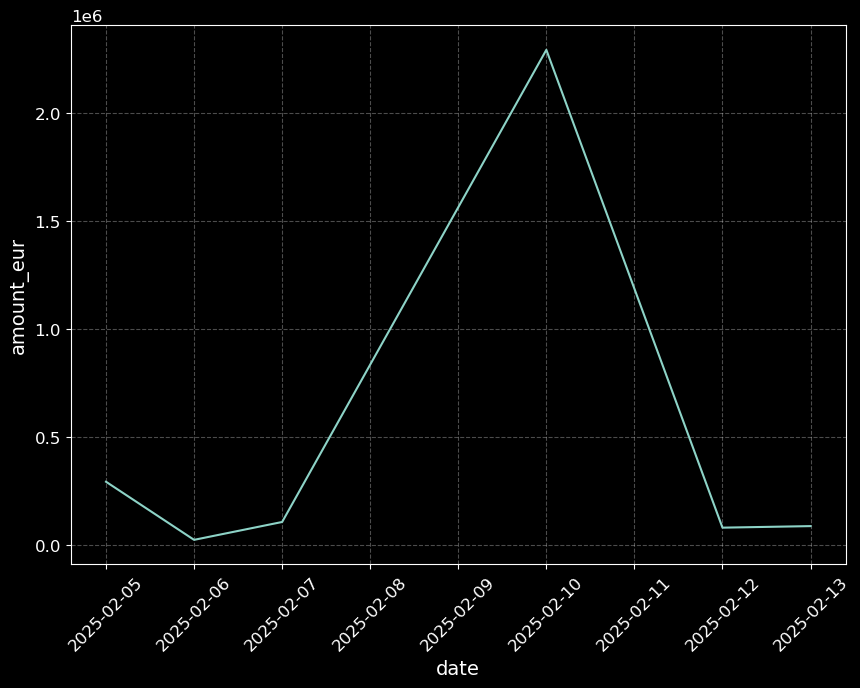

In [62]:
sns.lineplot(spike1, x = 'date', y='amount_eur')
plt.xticks(rotation=45)
plt.show()

In [63]:
start, end = '2025-02-05', '2025-02-11'

In [71]:
spike1_news = news[news.date.between(start, end)].daily_headers

In [72]:
for i in spike1_news:
    print(i)

['North Korea has sent 200 long-range artillery guns to Russia, Seoul says'] | ['Ukraine ‘may be Russian some day’, Trump says ahead of Zelenskyy meeting with Vance', 'Marc Fogel: Trump says another release to come as he greets US teacher freeed by Russia', 'Looking at Women, Looking at War by Victoria Amelina review – in memory of the Ukrainian novelist who catalogued war crimes', 'Zelenskyy: Europe cannot guarantee Ukraine’s security without America', 'Ukraine war briefing: Power restrictions as Russia hits energy system']
['Wounded Russian soldiers receiving treatment in North Korea, ambassador says'] | ['Ukraine war briefing: Trump plan to end war must include security guarantees, Zelenskyy says', 'Can Trump keep his promise to end the war in Ukraine? It’s possible – but it won’t be easy | Christopher Chivvis']
['Trump says he has spoken with Putin about ending Ukraine war', 'Trump’s sanctions against the ICC are disgraceful | Kenneth Roth', 'Ukraine war briefing: Kim Jong-un vows 

Overlaying news data on the donation chart reveals that anomalous corporate spikes (up to 2M/day) are a reaction to systemic macro-threats rather than local events.
Key period triggers:
North Korean troops entering the war (direct escalation).
Trump's statements on cutting US aid (risk of losing Western funding).
Renewed heavy strikes on the energy grid.

Business acts as a hedge: when external support wavers, they pump money directly into defense.
Let's see which companies made biggest donations

In [76]:
# Top 10 donators in spike1 period
df[df.date.between(start, end)].nlargest(10, 'amount_eur')

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start
1873871,4814795,2025-02-10,come_back_alive,general,"929,525.69",43.03,UAH,"ТОВ ""ОККО-ДРАЙВ"" -- Перерах. за Благодійна пожертва",Oschad,2025-02-10
1873794,4814715,2025-02-10,come_back_alive,general,"464,762.84",43.03,UAH,"ТОВ ""ОККО-ЕКСПРЕС"" -- Перерах. за Благодійна пожертва",Oschad,2025-02-10
1873941,4814598,2025-02-10,come_back_alive,general,"454,779.62",43.03,UAH,"ТОВ ""ОККО-ЛАЙТ"" -- Перерах. за Благодійна пожертва",Oschad,2025-02-10
1874367,4814231,2025-02-10,come_back_alive,general,"278,857.71",43.03,UAH,"ТОВ ""КОМПАНІЯ ОККО-БІЗНЕС"" -- Перерах. за Благодійна пожертва",Oschad,2025-02-10
1873898,4814822,2025-02-10,come_back_alive,general,"141,846.97",43.03,UAH,"ПРАТ ""КИЇВСТАР"" -- Оплата благ.внеску БО Повернись живим.Проект Нам тут жити...",Oschad,2025-02-10
1897231,4789945,2025-02-05,come_back_alive,general,"134,193.01",43.12,UAH,Благодійний платіж за 01.2025р. на користь БФ (Повернись живим),Universal,2025-02-03
1897457,4789867,2025-02-05,come_back_alive,general,"92,655.94",43.12,UAH,"ТОВ ""ОККО-ПОСТАЧ"" -- Перерах. за Благодійна пожертва",Oschad,2025-02-03
1897382,4789791,2025-02-05,come_back_alive,general,"39,056.52",43.12,UAH,"ПП ""ОККО-СЕРВІС"" -- Перерах. за Благодійна пожертва",Oschad,2025-02-03
1884769,7924047,2025-02-07,come_back_alive,general,"38,623.33",42.98,UAH,Благодійник -- Благодійна допомога,Privat,2025-02-03
1897223,4789936,2025-02-05,come_back_alive,general,"26,230.95",43.12,UAH,"ТОВ ""ОККО-АГРОТРЕЙД"" -- Перерах. за Благодійна пожертва",Oschad,2025-02-03


Drilling down into the peak reveals that the massive capital influx is driven exclusively by domestic Ukrainian corporations (e.g., OKKO Group, Kyivstar).
Unlike international donors, local businesses cannot relocate their physical infrastructure (gas stations, telecom networks).
For domestic corporations, funding the military is not charity or PR—it is a direct, calculated investment in their own physical survival and operational continuity.

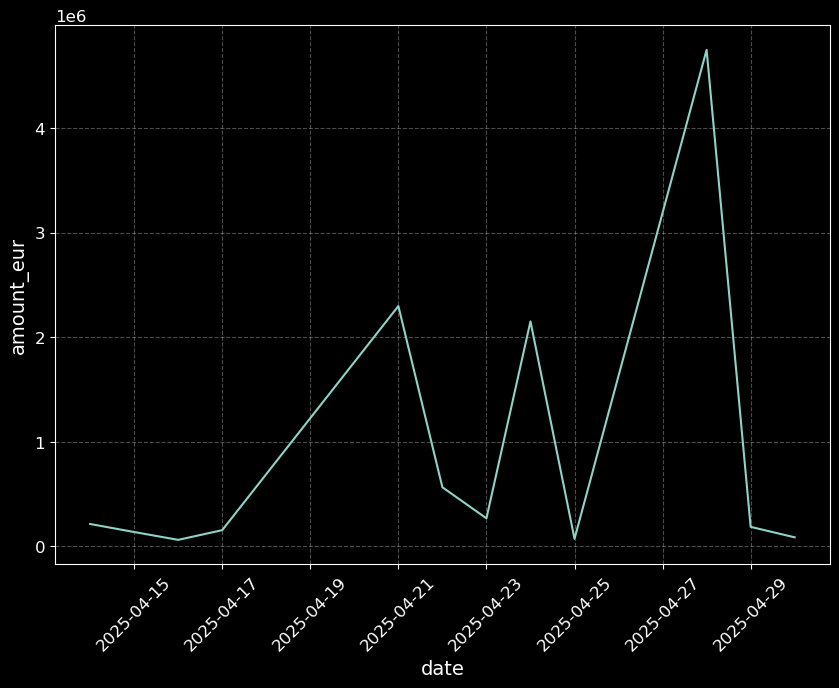

In [83]:
spike2 = daily_stats[daily_stats.date.between('2025-04-13', '2025-04-30')]
sns.lineplot(spike2, x = 'date', y='amount_eur')
plt.xticks(rotation=45)
plt.show()

In [84]:
start, end = '2025-04-13', '2025-04-30'

In [85]:
spike2_news = news[news.date.between(start, end)].daily_headers
for i in spike2_news:
    print(i)

['Inside Taganrog: beatings, electrocution and starvation at prison where Ukrainians were tortured', 'US ex-ambassadors warn of slide into authoritarianism amid ‘climate of fear’', 'Russia has offered a short ceasefire in Ukraine – but here’s what Putin really wants | Andriy Yermak', 'US and Ukraine sign minerals deal that solidifies investment in Kyiv’s defense against Russia', 'Ukraine war briefing: Ukrainian leaders lay out details of long-awaited minerals deal with US', 'Ukraine war briefing: UN slashes humanitarian aid after ‘sharp’ fall in funding']
['‘Numerous signs of torture’: a Ukrainian journalist’s detention and death in Russian prison', 'Carney says ‘Trump is trying to break us’ after Liberals win Canadian election | First Thing', 'Kemi revels in a Conservative electoral drubbing – in Canada of course | John Crace', 'Ukraine war briefing: Zelenskyy calls Putin’s offer of brief ceasefire ‘manipulation’', 'Trump 100 days: from cornerstone of the west to unreliable ally', 'Tr


Drilling down into the peak reveals that the surge in business donations is triggered by an institutional vacuum, not diplomatic optimism. Unlike individual donors who react to emotional tragedies, large businesses deploy capital in direct response to delayed foreign aid, fake ceasefires, and targeted infrastructure attacks.
For these corporations, stepping in to fund the military is not charity—it is a mandatory security and a direct substitution of state defense functions to ensure their own survival.

As this is a demonstration research, I won’t torture you by repeating the same analysis for all the other peaks. Let’s look at some other trends instead. For example, let’s compare the monthly box plots.

In [89]:
# Adding month column to cleaned df
df_clean['month'] = df.date.dt.to_period('M').dt.to_timestamp()

In [90]:
df_clean.head()

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start,month
3419,9682467,2026-04-08,come_back_alive,general,"179,029.30",50.27,UAH,"ТОВ ""ФЬОРСТ ЕЛЕМЕНТ"" -- Надання благодійної пожертви",Privat,2026-04-06,2026-04-01
3495,9682489,2026-04-08,come_back_alive,general,"179,029.30",50.27,UAH,"ТОВ ""ФЬОРСТ ЕЛЕМЕНТ"" -- Надання благодійної пожертви",Privat,2026-04-06,2026-04-01
3830,9682410,2026-04-08,come_back_alive,general,"280,209.29",50.27,UAH,"АКЦІОНЕРНЕ ТОВАРИСТВО ""ВІННИЦЯОБЛЕНЕРГО"" -- Надання безповоротної благодійно...",Privat,2026-04-06,2026-04-01
10155,9658878,2026-04-02,come_back_alive,general,"102,320.31",50.82,UAH,"ТОВ ""ВОРК УКРАЇНА"" -- Благодійний внесок для потреб військовослужбовців Сил ...",Privat,2026-03-30,2026-04-01
10156,9658879,2026-04-02,come_back_alive,general,"98,384.91",50.82,UAH,"СТОВ ""ЛНЗ-АГРО"" -- Благодійна допомога",Privat,2026-03-30,2026-04-01


In [115]:
# Group by month
monthly = df_clean.groupby('month', as_index=False).agg(
    total_amount=('amount_eur', 'sum'),      
    median_amount=('amount_eur', 'median'),  
    count=('amount_eur', 'count')            
)

In [141]:
monthly

,month,total_amount,median_amount,count,month_str
0,2025-01-01,"2,621,742.03","62,817.01",37,2025-01-01
1,2025-02-01,"4,363,259.42","34,602.56",54,2025-02-01
2,2025-03-01,"3,423,834.58","34,446.85",59,2025-03-01
3,2025-04-01,"12,132,750.41","51,588.74",52,2025-04-01
4,2025-05-01,"4,907,707.71","21,329.69",88,2025-05-01
5,2025-06-01,"3,849,537.37","20,993.97",81,2025-06-01
6,2025-07-01,"8,431,938.48","20,490.31",186,2025-07-01
7,2025-08-01,"3,474,218.24","20,677.24",136,2025-08-01
8,2025-09-01,"4,943,057.16","20,774.99",159,2025-09-01
9,2025-10-01,"6,747,627.27","20,774.19",174,2025-10-01


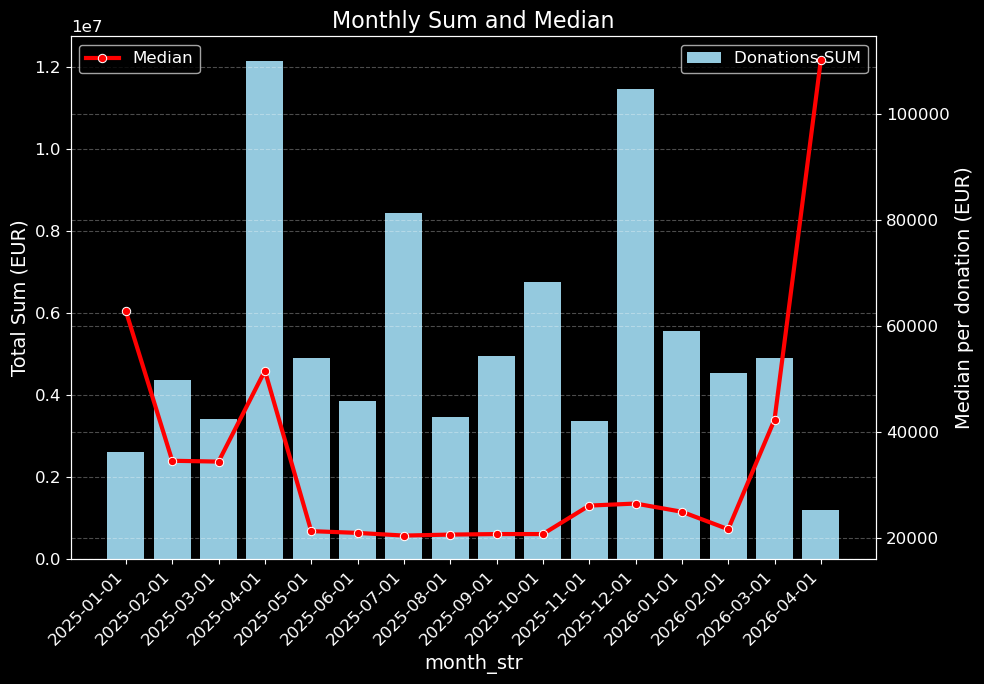

In [138]:
monthly['month_str'] = monthly['month'].astype(str)

ax = sns.barplot(monthly, x='month_str', y='total_amount', color='skyblue', 
                 order=sorted(monthly['month_str'].unique()), label = 'Donations SUM')
# Making secong axis on the rigth
ax2 = ax.twinx()

sns.lineplot(monthly, x='month_str', y='median_amount', estimator=None, 
             marker='o', linewidth=3, color='red', ax=ax2, label = 'Median')

for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.xlabel('Month')
ax.set_ylabel('Total Sum (EUR)')
ax2.set_ylabel('Median per donation (EUR)')
plt.title('Monthly Sum and Median')
plt.legend()
plt.tight_layout()
plt.show()

Very busy March, isn't it? Let's take a closer look.
Also I'm glad to notice, that this year donations started to grow twice as usual! Again - in March!

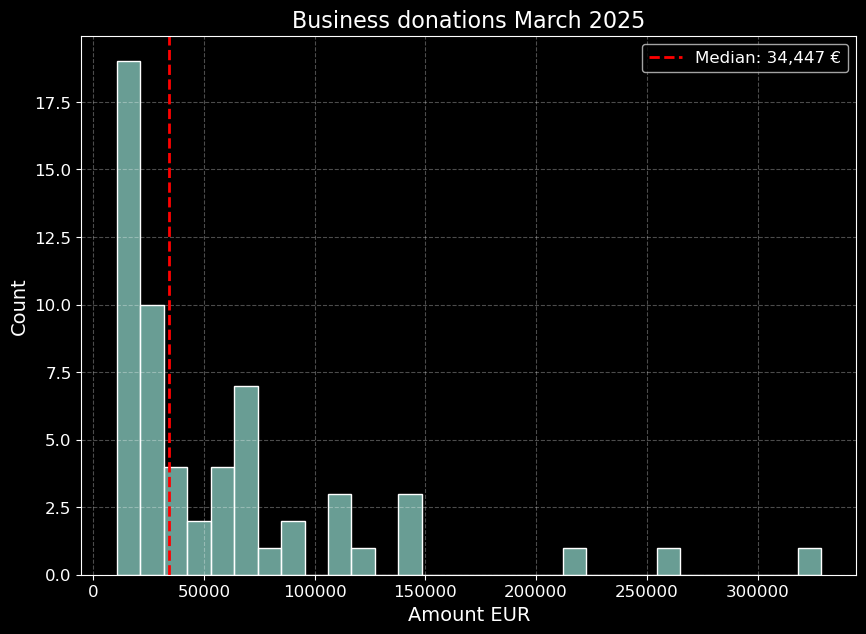

In [139]:
# Build a histogram of business donations in March
march = df_clean[df_clean.month == '2025-03-01']
median_value = march['amount_eur'].median()
ax = sns.histplot(march.amount_eur, bins = 30)
ax.axvline(
    x=median_value, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Median: {median_value:,.0f} €'
)
plt.title('Business donations March 2025')
plt.xlabel('Amount EUR')
plt.legend()
plt.show()

Alright, we see that this big sum wasn’t contributed solely by the whales. Apparently, Trump’s humiliation of Zelensky and his refusal to help Ukraine also triggered small businesses to donate. 

Now let's find Whales share of overall business donations during the whole period (since January 1, 2025)

In [151]:
# Finding Whales (over 95% percentile)
whales = df_clean[df_clean.amount_eur >= df_clean.amount_eur.quantile(q = 0.95)]
whales.shape[0]

74

In [174]:
# Top 7 multiple donations from Whales
whales.groupby('comment', as_index = False)\
                                .agg(total_sum = ('amount_eur', 'sum'),
                                     total_donations_count = ('id', 'count'),
                                     currency = ('original_currency', 'first'))\
                                .sort_values('total_donations_count', ascending = False)\
                                .reset_index(drop = True).head(7)                                

,comment,total_sum,total_donations_count,currency
0,"ПРАТ ""УКРГІДРОЕНЕРГО"" -- Пожертва згідно з","4,856,131.02",9,UAH
1,Публiчне акцiонерне товариство 'Укрнафта' -- Безповоротна фiнансова благодiй...,"1,895,293.15",8,UAH
2,"Акціонерне товариство ""Укрнафта -- Безповоротна фінансова благодійна допомога","1,585,904.80",4,UAH
3,"ТОВ ""КОМПАНІЯ ОККО-БІЗНЕС"" -- Благодійна пожертва","1,224,864.56",3,UAH
4,"ТОВ ""ОККО-ЕКСПРЕС"" -- Благодійна пожертва","1,204,118.66",3,UAH
5,"ТОВ ""ОККО-ДРАЙВ"" -- Благодійна пожертва","1,040,960.84",2,UAH
6,"АТ ""КОНЦЕРН ГАЛНАФТОГАЗ"" -- Благодійна пожертва","945,996.64",2,UAH


Sadly, only Ukrainian big businesses. Let's see total SUM of Whales donations

In [183]:
print(f'''Total sum of Whales donations is: {whales.amount_eur.sum()}\nTotal sum of business donations is: {df_clean.amount_eur.sum()}
Share of Whales in overall business donations: {round(whales.amount_eur.sum()/df_clean.amount_eur.sum()*100, 2)}%''')

Total sum of Whales donations is: 38274792.99
Total sum of business donations is: 85919445.26
Share of Whales in overall business donations: 44.55%


Wow, that's impressive! Only 5% of business donors account for 44.55% of the total business donations.
Are there any non-domestic Whales here?

In [189]:
foreign_whales = whales[whales.original_currency != 'UAH']
#top 7 foreign Whales
foreign_whales.nlargest(7, 'amount_eur')

,id,date,foundation_name,category,amount_eur,eur_exchange_rate,original_currency,comment,donation_source,week_start,month
1180134,5625329,2025-07-03,come_back_alive,general,"2,127,479.00",49.13,USD,"""For the needs of Ukrainian Defence""",Universal,2025-06-30,2025-07-01
1461712,7623153,2025-04-28,come_back_alive,general,"1,722,495.16",47.39,EUR,DONATION: COME BACK ALIVE ORG. DONATION: COME BACK ALIVE ORG.,Universal,2025-04-28,2025-04-01
1461934,5336955,2025-04-28,come_back_alive,general,"1,600,219.48",47.39,EUR,Fritt Ukraina -- CHARITABLE WORK (1 600 000.00 EUR),Privat,2025-04-28,2025-04-01
231569,9425984,2026-01-26,come_back_alive,general,"1,030,572.18",50.65,CZK,Post Bellum -- (25 000 000.00 CZK),Privat,2026-01-26,2026-01-01
1473018,5328188,2025-04-24,come_back_alive,general,"1,000,000.00",47.54,EUR,Fritt Ukraina -- DRONEFALL 1.0 (1 000 000.00 EUR),Privat,2025-04-21,2025-04-01
1473016,5328147,2025-04-24,come_back_alive,general,"997,370.75",47.54,EUR,Fritt Ukraina -- DRONEFALL 2.0 (1 000 000.00 EUR),Privat,2025-04-21,2025-04-01
18071,9654237,2026-03-30,come_back_alive,general,"989,975.68",50.49,USD,For the needs of Ukrainian Defence DD 27.03.2026 (1 140 055.00 USD),Privat,2026-03-30,2026-03-01


In [192]:
# Foreign Whales donation SUM and share of overall whales donations
foreign = foreign_whales.amount_eur.sum()
overall = whales.amount_eur.sum()
share   = round(foreign/overall*100, 2)

In [194]:
print(f'Total donations SUM from foreign Whales is: {round(foreign, 2)}\nTotal share of foreign Whales is: {share}%')

Total donations SUM from foreign Whales is: 11678273.7
Total share of foreign Whales is: 30.51%


30% is quite impressive, isn't it? It shows that foreign businesses clearly understand the threat of Ukraine losing the war to russia.